# 📝 Instrucciones

## Sistema de detección de enlaces spam

Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

### Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre `url_spam.csv`. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv

O descargarlo y añadirlo a mano en tu repositorio.

### Paso 2: Preprocesa los enlaces
Utiliza lo visto en este módulo para transformar los datos para compatibilizarlos con el modelo que queremos entrenar. Segmenta las URLs en partes según sus signos de puntuación, elimina las stopwords, lematiza, etcétera.

Asegúrate de dividir convenientemente el conjunto de datos en `train` y `test` como hemos visto en lecciones anteriores.

### Paso 3: Construye un SVM
Comienza a resolver el problema implementando un SVM con los parámetros por defecto. Entrénalo y analiza sus resultados.

### Paso 4: Optimiza el modelo anterior
Después de entrenar el SVM, optimiza sus hiperparámetros utilizando un grid search o un random search.

### Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [264]:
import os
import joblib
import regex as re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve
from collections import Counter
from imblearn.over_sampling import SMOTE
from scipy.stats import loguniform
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Andres\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Andres\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Andres\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [265]:
# Cargamos el dataset de URLs
df = pd.read_csv('../data/raw/url_spam.csv', delimiter = ",")
df.head(3)

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True


In [266]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB


In [267]:
# Aplicamos lo visto en el modulo de 4geeks y  convertimos la variable categorica "is_spam" a "numerica"
df["is_spam"] = df["is_spam"].apply(lambda x: 1 if x == True else 0).astype(int)
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1


In [268]:
# Vemos las dos clases y su balance
print(df.shape)
print(f"Spam: {len(df.loc[df.is_spam == 1])}")
print(f"No spam: {len(df.loc[df.is_spam == 0])}")

(2999, 2)
Spam: 696
No spam: 2303


In [269]:
# Eliminamos duplicados
df = df.drop_duplicates()
df = df.reset_index(inplace = False, drop = True)
df.shape

(2369, 2)

In [270]:
# Como dicen en el modulo hay que hacer limpiar y luego "lematizar" pero con unos ajustes porque no tenemos una frase sino una url
def preprocess_url(url):
    # Reemplazamos signos de puntuación por espacios
    url = re.sub(r'[^\w\s]', ' ', url)
    
    # Convertimos a minusculas y dividimos por espacios(osea tokenizamos)
    tokens = url.lower().split()
    
    # Eliminar stop words como vimos en clases (palabras como 'the', 'is', 'http', 'www', etc)
    stop_words = set(stopwords.words('english'))
    
    # No se si la libreria de nltk las incluya pero igual añadimos terminos comunes de URLs a las stopwords
    custom_stops = {'http', 'https', 'www', 'com', 'html', 'php'}
    stop_words.update(custom_stops)
    
    tokens = [w for w in tokens if w not in stop_words]
    
    #Hacemos la lematizacion reduciendo palabras a su base por asi decirlo ejemplo: "running" a "run"
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    #Eliminamos tokens de un solo caracter y numeros aislados
    tokens = [w for w in tokens if len(w) > 1 and not w.isdigit()]
    
    return tokens

# Aplicamos la funcion
df["url"] = df["url"].apply(preprocess_url)


In [271]:
df

,url,is_spam
0,"[briefingday, us8, list, manage, unsubscribe]",1
1,[hvper],1
2,"[briefingday, v4n3i4f3]",1
3,"[briefingday, commentform]",0
4,"[briefingday, fan]",1
...,...,...
2364,"[theverge, disney, deepfake, face, swapping, r...",0
2365,"[smartcitiesworld, net, news, news, deepfake, ...",0
2366,"[techcrunch, optimistic, view, deepfakes]",0
2367,"[technologyreview, startup, claim, deepfakes, ...",0


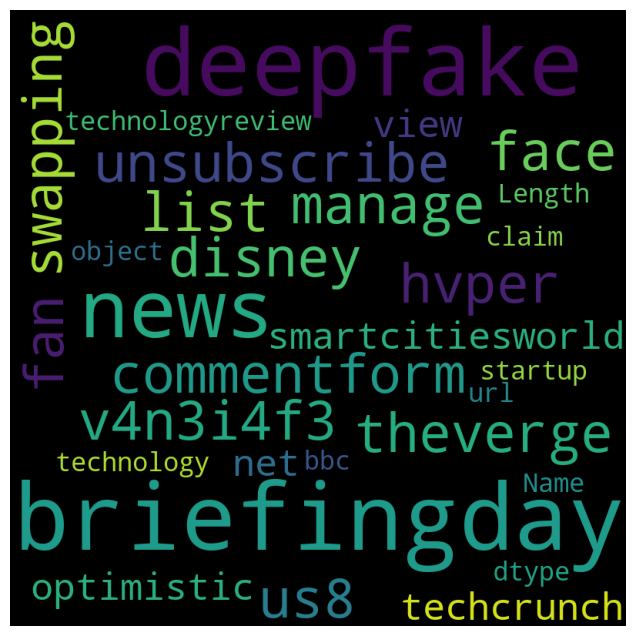

In [272]:
# Hacemos una nube de paabras, una representacion visual de las palabras que componen un texto.
wordcloud = WordCloud(width = 800, height = 800, background_color = "black", max_words = 1000, min_font_size = 20, random_state = 42)\
    .generate(str(df["url"]))

fig = plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Analizis inicial:
* tenemos un dataframe de 2 columnas url(str) y is_spam (bool)
* inicialmente tenia 2999 filas pero eliminando duplicados quedaron 2369.
* Hay desbalance de clases (Spam: 696, No spam: 2303)
* palabras como deepfake, briefingday, disney, unsuscribe, etc son las mas populares y propensas a ser spam.

In [273]:
#ya que los modelos no pueden entrenar con categorias textuales convertimos los valores a numeros. con "TfidfVectorizer"
tokens_list = df["url"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]

vectorizer = TfidfVectorizer(max_features = 5000, max_df = 0.8, min_df = 5)
X = vectorizer.fit_transform(tokens_list).toarray()
y = df["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 625))

In [274]:
# Separamos los datos en un 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [275]:
# Declaramos y entrenamos el modelo de una forma basica.
model_svc = SVC(kernel = "linear", random_state = 42)
model_svc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [276]:
# Vemos las predicciones y se las pasamos al "classification_report"
y_pred = model_svc.predict(X_test)
metrics_svc = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       435
           1       0.88      0.54      0.67        39

    accuracy                           0.96       474
   macro avg       0.92      0.77      0.82       474
weighted avg       0.95      0.96      0.95       474



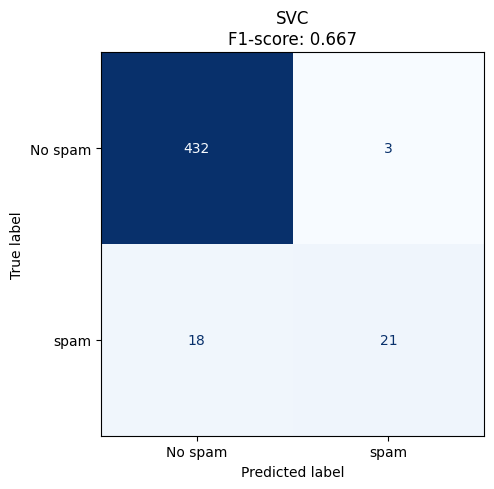

In [277]:
# Dibujemos una matriz de confucion
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))


cm_base = confusion_matrix(y_test, y_pred)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["No spam", "spam"])
disp_base.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"SVC\nF1-score: {metrics_svc['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()

### Analizis hasta ahora:
El modelo sin parametros nos da un resultado bueno para identificar los no spam(un 0.98 de f1) pero un resultado mediocre(0.54 recall) para los spam que son los que nos interez identificar, el modelo no puede permitirse tener un recall bajo porque hace que solo identifiquemos pocos dejando por fuera posibles spam.

### Ahora que sigue?
* Por ahora solo hagamos oversampling o cualquier metodo para ajustar el desbalance de clases.
* Despues Probaremos la vieja confiable "RamdomGridSearch junto con GridSearch" para buscar los mejores parametros.


In [278]:
# SMOTE crea ejemplos sinteticos basados en vecinos cercanos
smote = SMOTE(random_state=42)
X_over, y_over = smote.fit_resample(X_train, y_train)
print(f"Distribucion tras SMOTE: {Counter(y_over)}")

Distribucion tras SMOTE: Counter({0: 1690, 1: 1690})


In [279]:
#Volvamos a entrenar a ver si algo ha cambiado
model_svc_over = SVC(kernel = "linear", random_state = 42)
model_svc_over.fit(X_over, y_over)
y_pred_over = model_svc_over.predict(X_test)
metrics_svc_over = classification_report(y_test, y_pred_over, output_dict=True)
print(classification_report(y_test, y_pred_over))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90       435
           1       0.30      0.82      0.44        39

    accuracy                           0.82       474
   macro avg       0.64      0.82      0.67       474
weighted avg       0.92      0.82      0.86       474



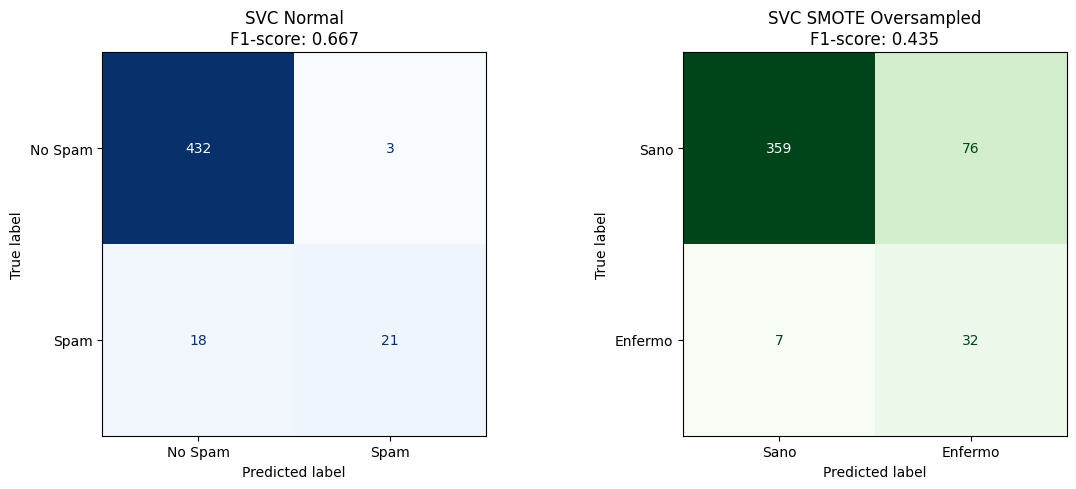

In [280]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Normal
cm_base = confusion_matrix(y_test, y_pred)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["No Spam", "Spam"])
disp_base.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"SVC Normal\nF1-score: {metrics_svc['1']['f1-score']:.3f}")

# OverSampled
cm_over = confusion_matrix(y_test, y_pred_over)
disp_over = ConfusionMatrixDisplay(confusion_matrix=cm_over, display_labels=["Sano", "Enfermo"])
disp_over.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"SVC SMOTE Oversampled\nF1-score: {metrics_svc_over['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()

### Interpretacion: 
Como vemos el sampling de SMOTE ha bajado el f1, pero tambien ha mejorado las predicciones de los spam rediciendo los 18 falsos positivos a 7.
Ahora vamos a hacer un ramdongrrid search junto con gridsearch para buscar los mejores parametros. Traigamos el codigo del ejercicio 8:

In [282]:
# Como hicimos en el ejercicio 8 declaremos cual va a ser nuestro scoring objetivo
scoring = 'roc_auc'
#Definimos cuantos "try's" va a tener nuestro StratifiedKFold
n_splits = 5
cv = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = 42)

folder = '../data/processed/models/spamsvc/'
file = 'model_svc.pkl'
path = folder + file

if not os.path.exists(path):
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    # Inicializamos el modelo SVC
    
    base_model = SVC(probability=True)

    # Buscando en internet vi que para C y gamma es mejor usar loguniform que un rango convencional.
    random_params = {
        "C": loguniform(1e-3, 1e3),          
        "gamma": loguniform(1e-4, 1e1),     
        "kernel": ['linear', 'rbf', 'poly', 'sigmoid'],
        "degree": [2, 3, 4],
        "class_weight": [None, 'balanced',{0:1, 1:2}, {0:1, 1:3}, {0:1,1:4}]
    }
    
    # Configuramos el RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator = base_model,
        param_distributions = random_params,
        n_iter = 60,                       
        scoring = scoring, 
        cv = cv,
        random_state = 42,
        n_jobs = -1,
        verbose = 1                     
    )
    print("Iniciando RandomizedSearchCV...")
    random_search.fit(X_train, y_train)
    
    model_grid = random_search.best_estimator_
   
    print(f"Mejores parametros encontrados: {random_search.best_params_}")
    print(f"Mejor score: {random_search.best_score_:.4f}")
  
else:
    model_grid = joblib.load(path)
    print("Modelo SVC cargado exitosamente.")

Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores parametros encontrados: {'C': np.float64(9.443515687962675), 'class_weight': 'balanced', 'degree': 3, 'gamma': np.float64(0.039841905944346875), 'kernel': 'rbf'}
Mejor score: 0.9146


In [ ]:
# Ahora el GridSearchCV tomando en cuanta lo que obtubimos con el RandomizedSearchCV, lo mismo que con el ejercicio 8
def range_params(param, steps=2, step_size=1, min_val=0.0001):
    param_list = []
    decimals = max(0, -int(round(np.log10(step_size)))) if step_size < 1 else 0
    
    for i in range(steps, 0, -1):
        val = round(param - i*step_size, decimals)
        if val >= min_val:
            param_list.append(val)
    param_list.append(param)
    for i in range(1, steps+1):
        param_list.append(round(param + i*step_size, decimals))
    return sorted(list(set(param_list)))

if not os.path.exists(path):
    if not os.path.exists(folder):
        os.makedirs(folder)
    # Extraemos los mejores parametros del RandomizedSearch anterior
    best_params = random_search.best_params_

    # Construimos el grid refinado
    # Ajustamos C y Gamma basándonos en el mejor valor encontrado
    grid_params = {
        "C": range_params(best_params["C"], steps=3, step_size=best_params["C"]*0.2, min_val=0.001),
        # si gamma 
        "gamma": range_params(best_params["gamma"], steps=3, step_size=best_params["gamma"]*0.2, min_val=0.0001) if "gamma" in best_params else [best_params.get("gamma", 'scale')],
        "kernel": [best_params["kernel"]],
        "class_weight": [best_params["class_weight"]]
    }

    # Si el mejor kernel fue 'poly', vo que podemos refinar el "grado" tambien
    if best_params["kernel"] == "poly":
        grid_params["degree"] = range_params(best_params["degree"], steps=1, step_size=1, min_val=2)

    # Ejecutamos el GridSearchCV
    grid_search = GridSearchCV(
        estimator = SVC(probability=True),
        param_grid = grid_params,
        scoring = scoring,
        cv = cv,
        n_jobs = -1,
        verbose = 1
    )
    
    print("Iniciando refinamiento con GridSearchCV...")
    grid_search.fit(X_train, y_train)
    
    # Guardamos el modelo final
    model_grid = grid_search.best_estimator_
    joblib.dump(model_grid, path)
    
    print(f"Mejor combinacion final: {grid_search.best_params_}")
    print(f"Precision final: {grid_search.best_score_:.4f}")

else:
    model_grid = joblib.load(path)
    print("Modelo SVC cargado desde el disco.")

Iniciando refinamiento con GridSearchCV...
Fitting 5 folds for each of 28 candidates, totalling 140 fits
Mejor combinacion final: {'C': np.float64(0.1767016940294795), 'class_weight': {0: 1, 1: 4}, 'gamma': np.float64(0.2), 'kernel': 'linear'}
Precision final: 0.9228


In [283]:
# Vemos las metricas del nuevo modelo
model_grid.fit(X_train, y_train)
predict_grid = model_grid.predict(X_test)
metrics_grid = classification_report(y_test, predict_grid, output_dict = True)
print(classification_report(y_test, predict_grid))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91       435
           1       0.33      0.85      0.48        39

    accuracy                           0.85       474
   macro avg       0.66      0.85      0.69       474
weighted avg       0.93      0.85      0.88       474



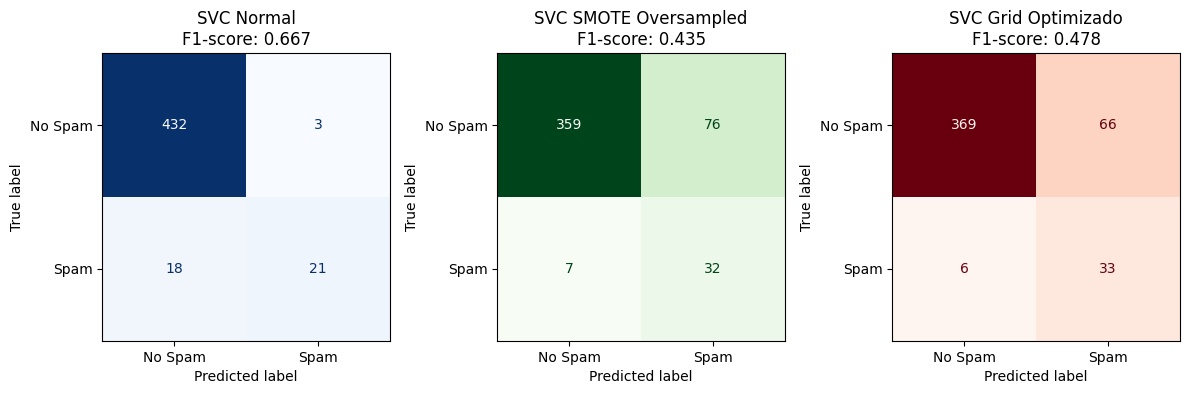

In [284]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Normal
cm_base = confusion_matrix(y_test, y_pred)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["No Spam", "Spam"])
disp_base.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"SVC Normal\nF1-score: {metrics_svc['1']['f1-score']:.3f}")

# OverSampled
cm_over = confusion_matrix(y_test, y_pred_over)
disp_over = ConfusionMatrixDisplay(confusion_matrix=cm_over, display_labels=["No Spam", "Spam"])
disp_over.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"SVC SMOTE Oversampled\nF1-score: {metrics_svc_over['1']['f1-score']:.3f}")

# Grid Optimizado
cm_grid = confusion_matrix(y_test, predict_grid)
disp_grid = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=["No Spam", "Spam"])
disp_grid.plot(ax=ax3, cmap='Reds', colorbar=False)
ax3.set_title(f"SVC Grid Optimizado\nF1-score: {metrics_grid['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()